**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: Dario Martin Romero Cruz
*   MATRÍCULA: A01841015

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [2]:
#Generar Dataframe con los datos
Data0 = pd.read_csv('personal_loan.csv', sep = ',', index_col = 'ID')
ColNum = list(Data0.dtypes.loc[Data0.dtypes.astype(str).isin(['int64', 'float64', 'int', 'float'])].index) #Lista de columnas numericas
ColNoNum = list(Data0.dtypes.loc[Data0.dtypes.astype(str).isin(['string', 'object'])].index) #Lista de columnas string

#Imprimir resultados
print('Tipos de datos de nuestro archivo:\n')
Data0.info()

print(f'\nTotal de filas: {Data0.shape[0]}')
print(f'Total de columnas: {Data0.shape[1]}')

print(f'  > Numericas: {len(ColNum)}')
print(f'  > No numericas: {len(ColNoNum)}')


Tipos de datos de nuestro archivo:

<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB

Total de filas: 5037
Total de columnas: 13
  > Numericas: 8
  

# Limpieza

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

In [3]:
#Realizar estadistica descriptiva sobre el subconjunto de datos
print('Estadistica descriptiva de las variables numericas:\n')
print(Data0[ColNum].describe(percentiles = [0.05, 0.95]).round(2))

#Filtrado / limpieza de datos por edad
f0 = Data0.Age > 100

#Filtrado / limpieza de datos por otras categorias
f1 = Data0.Experience < 0 #Clientes con experiencia negativa
f2 = Data0.Family < 0 #Clientes con un numero negativo de miembros de la familia
f3 = ~Data0.Education.isin([1, 2, 3]) #Clientes con nivel educativo diferente a los tipos definidos: 1, 2, 3
f4 = Data0['ZIP Code'] < 90000

#Imprimir resultados
print(f'\nClientes con edad mayor a 100 años ({','.join(list(Data0.loc[f0, 'Age'].astype(str).unique()))}): {sum(f0)} ({sum(f0)/Data0.shape[0]:.2%})')
print(f'\nClientes con experiencia laboral negativa: {sum(f1)} ({sum(f1)/Data0.shape[0]:.2%})')
print(f'Clientes con numero de miembros de la familia negativa: {sum(f2)} ({sum(f2)/Data0.shape[0]:.2%})')
print(f'Clientes con nivel educativo invalido (diferente a 1, 2, 3): {sum(f3)} ({sum(f3)/Data0.shape[0]:.2%})')
print(f'Clientes con ZIP CODE invalido ({','.join(list(Data0.loc[f4, 'ZIP Code'].astype(str).unique()))}): {sum(f4)} ({sum(f4)/Data0.shape[0]:.2%})')

#Aplicar cambios
f = f0|f1|f2|f3|f4
Data = Data0.loc[~(f0|f1|f2|f3|f4)].copy()
print(f'\nTotal de registros eliminados: {sum(f)} ({sum(f)/Data0.shape[0]:.2%})')

#Realizar estadistica descriptiva sobre datos actualizados
print('\nEstadistica descriptiva de las variables numericas de los datos limpios:\n')
print(Data[ColNum].describe(percentiles = [0.05, 0.95]).round(2))


Estadistica descriptiva de las variables numericas:

           Age  Experience   Income  ZIP Code   Family    CCAvg  Education  \
count  5037.00     5037.00  5037.00   5037.00  5037.00  5037.00    5037.00   
mean     45.41       20.12    73.90  93152.87     2.39     1.94       1.88   
std      11.65       11.46    46.13   2119.64     1.15     1.76       0.84   
min      23.00       -3.00     8.00   9307.00    -3.00     0.00       1.00   
5%       27.00        2.00    18.00  90072.60     1.00     0.10       1.00   
50%      45.00       20.00    64.00  93437.00     2.00     1.50       2.00   
95%      63.00       38.00   171.00  95670.00     4.00     6.00       3.00   
max     144.00       43.00   224.00  96651.00     4.00    10.00       7.30   

       Mortgage  
count   5037.00  
mean      56.50  
std      101.66  
min        0.00  
5%         0.00  
50%        0.00  
95%      272.00  
max      635.00  

Clientes con edad mayor a 100 años (123,144,130): 3 (0.06%)

Clientes con experie

**Justificación de Registros Eliminados.**  
1. Se tienen 3 registros con **Age** mayor a 100 años, con valores: 123, 130 y 144. Sin embargo, aunque estas edades podrían ser reales, haciendo una investigación encontré que el record de la persona más longeva de la historia corresponde a Jeanne Calment de 122 años. Por lo que estos valores no pueden estar correctos.
2. Dado que **Experiencie** representa los años de experiencia laboral de los clientes y **Family** es el número de miembros de su familia, un primer supuesto es que estos atributos solo pueden aceptar valores mayores o iguales a cero. Sin embargo, en la estadistica descriptiva se observaba que tenían mínimos negativos. Así los filtros **f1** y **f2** se realizan para omitir estos outliers.
3. Se sabe que **Education** solo puede tomar 3 posibles valores: 1, 2 y 3. Se utiliza el filtro **f3** para quitar los registros que tengan otro valor.
4. Se puede ver que casi todos los valores en **ZIP Code** estan entre 90071 y 96651, lo cual corresponde a la zona oeste de USA, especialmente california. Excepto un valor: 9307, el cual no es un código postal válido en USA. Por su forma probablemente sea un typo, faltandole un digito. Como no sabemos cual sea su valor real, también lo podemos descartar.
5. El resto de los parámetros no muestran evidencia de contener outliers.

3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [4]:
#Realizar estadistica descriptiva sobre el subconjunto de datos
print('Estadistica descriptiva de las variables no numericas:\n')
print(Data[ColNoNum].describe())

#Imprimir las frecuencias de cada uno de los datos por categoria
for Col in ColNoNum:
    print(f'\nParametro: {Col}')
    for i, Row in Data[Col].value_counts().reset_index().sort_values(Col).iterrows():
        print(f'{Row[Col]}: {Row['count']}')

#Cambiar Yes -> 1, No -> 0
Data[ColNoNum] = Data[ColNoNum].replace({'Yes': 1, 'No': 0}).astype(int)

#Realizar estadistica descriptiva sobre los datos actualizados
print('Estadistica descriptiva actualizada:\n')
print(Data[ColNoNum].describe())

Estadistica descriptiva de las variables no numericas:

       Personal Loan Securities Account CD Account Online CreditCard
count           4977               4977       4977   4977       4977
unique             4                  4          4      4          4
top                0                 No         No    Yes          0
freq            3475               2693       2462   1700       2628

Parametro: Personal Loan
0: 3475
1: 117
No: 1017
Yes: 368

Parametro: Securities Account
0: 1765
1: 129
No: 2693
Yes: 390

Parametro: CD Account
0: 2212
1: 163
No: 2462
Yes: 140

Parametro: Online
0: 374
1: 1275
No: 1628
Yes: 1700

Parametro: CreditCard
0: 2628
1: 557
No: 885
Yes: 907
Estadistica descriptiva actualizada:

       Personal Loan  Securities Account   CD Account       Online  \
count    4977.000000         4977.000000  4977.000000  4977.000000   
mean        0.097448            0.104280     0.060880     0.597750   
std         0.296597            0.305654     0.239134     0.4904

4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

In [5]:
#Identificar duplicados
f = Data.duplicated(keep = 'first')

#Eliminar duplicados
Data = Data.loc[~f].copy().reset_index(drop = True)

#Imprimir resultados
print(f'Cantidad de registros duplicados: {sum(f)}')

Cantidad de registros duplicados: 36


5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [6]:
#Columnas nominales
Data['ZIP Code'] = Data['ZIP Code'].astype(object)

#Columnas ordinales
Data['Education'] = Data.Education.astype('category')
Data['Education'] = Data.Education.cat.set_categories([1, 2, 3], ordered = True)

#Columnas binarias
Cols = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
Data[Cols] = Data[Cols].astype('category')

#Imprimir resultados de tipos para validar
print('Tipos de datos de nuestro archivo despues de actualizacion:\n')
Data.info()

#Definir listas de columnas segun tipo de datos
num_cols = list(Data.dtypes.loc[Data.dtypes.astype(str).isin(['int64', 'float64', 'int', 'float'])].index) #Lista de columnas numericas
cat_cols = list(Data.dtypes.loc[Data.dtypes.astype(str).isin(['string', 'object', 'category'])].index) #Lista de columnas categoricas

print(f'\nColumnas numericas: {', '.join(num_cols)}')
print(f'Columnas categoricas: {', '.join(cat_cols)}')


Tipos de datos de nuestro archivo despues de actualizacion:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4941 entries, 0 to 4940
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 4941 non-null   int64   
 1   Experience          4941 non-null   int64   
 2   Income              4941 non-null   int64   
 3   ZIP Code            4941 non-null   object  
 4   Family              4941 non-null   int64   
 5   CCAvg               4941 non-null   float64 
 6   Education           4941 non-null   category
 7   Mortgage            4941 non-null   int64   
 8   Personal Loan       4941 non-null   category
 9   Securities Account  4941 non-null   category
 10  CD Account          4941 non-null   category
 11  Online              4941 non-null   category
 12  CreditCard          4941 non-null   category
dtypes: category(6), float64(1), int64(5), object(1)
memory usage: 299.9+ KB

Colu

# Análisis exploratorio de datos (univariado)

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.

In [7]:
#Obtener estadísticas de las "nuevas" columnas numericas
Stat = Data[num_cols].describe(percentiles = [0.05, 0.95])
Stat = pd.concat([Stat, Data[num_cols].agg(['skew', 'kurt'])]) #Agregar sesgo y curtosis

#Imprimir resultados
print('Estadistica descriptiva de las variables numericas\n')
print(Stat.round(2))
print('\nAnalisis de Sesgo y Curtosis:')

#Clasificar Age, Income, Mortgage
for Col in ['Age', 'Income', 'Mortgage']:
    s = Stat.loc['skew', Col]
    k = Stat.loc['kurt', Col]
    sTyp = 'Aproximadamente Simetrica' if abs(s) < 0.5 else 'Ligeramente Simetrica' if abs(s) < 1 else 'Asimetrica'
    kTyp = 'Platicurtica' if k < -0.5 else 'Aproximadamente Mesocurtica' if k < 0.5 else 'Leptocurtica'
    
    print('\n' + Col)
    print(f'  > Tipo de sesgo: {sTyp}')
    print(f'  > Tipo de curtosis: {kTyp}')

Estadistica descriptiva de las variables numericas

           Age  Experience   Income   Family    CCAvg  Mortgage
count  4941.00     4941.00  4941.00  4941.00  4941.00   4941.00
mean     45.56       20.34    73.83     2.39     1.94     56.66
std      11.32       11.31    46.11     1.15     1.75    101.88
min      24.00        0.00     8.00     1.00     0.00      0.00
5%       28.00        3.00    18.00     1.00     0.10      0.00
50%      46.00       20.00    64.00     2.00     1.50      0.00
95%      63.00       38.00   171.00     4.00     6.00    272.00
max      67.00       43.00   224.00     4.00    10.00    635.00
skew     -0.02       -0.02     0.84     0.16     1.59      2.10
kurt     -1.16       -1.13    -0.05    -1.40     2.64      4.76

Analisis de Sesgo y Curtosis:

Age
  > Tipo de sesgo: Aproximadamente Simetrica
  > Tipo de curtosis: Platicurtica

Income
  > Tipo de sesgo: Ligeramente Simetrica
  > Tipo de curtosis: Aproximadamente Mesocurtica

Mortgage
  > Tipo de sesgo: 

7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

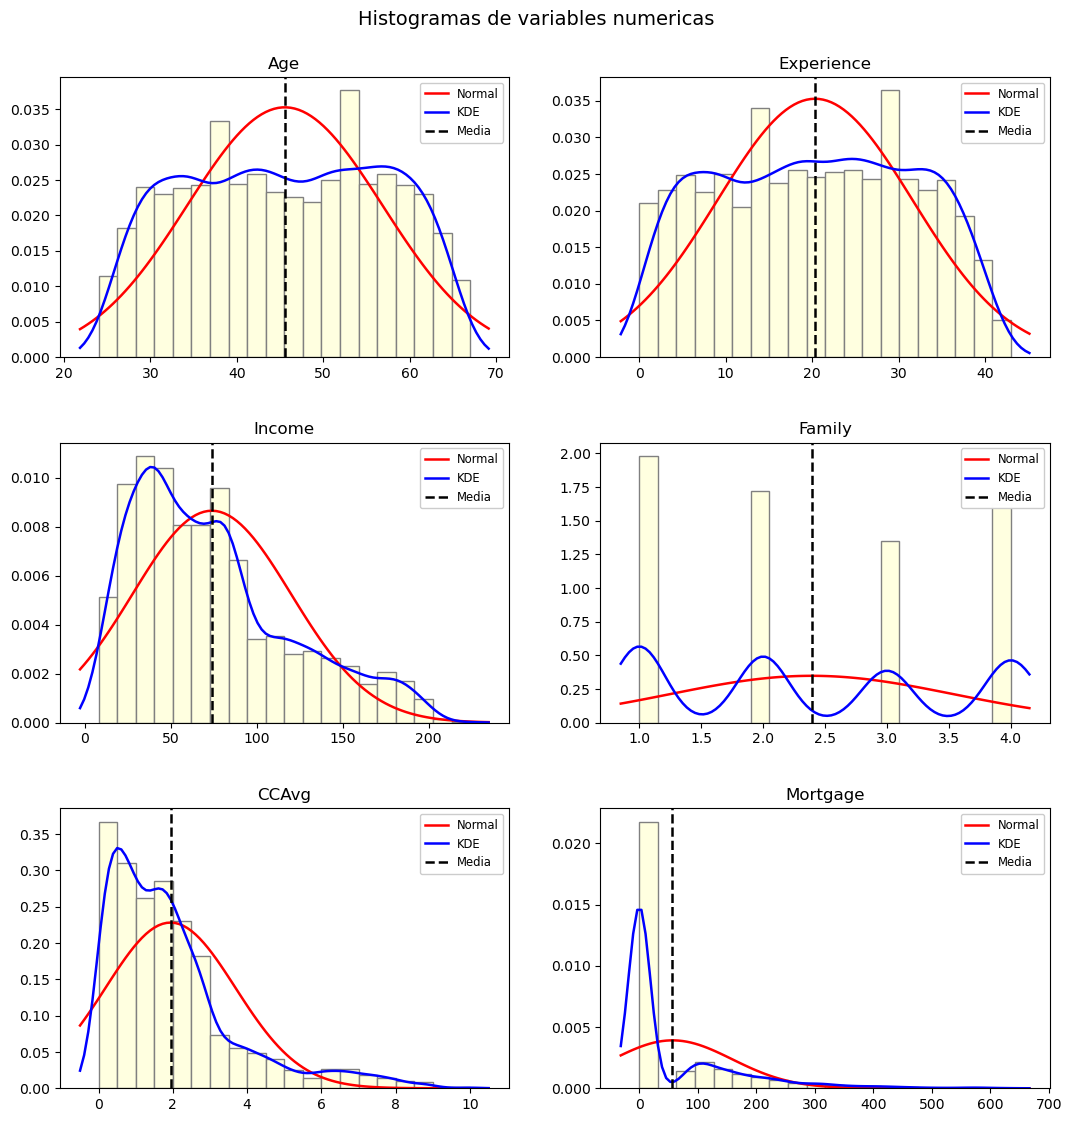

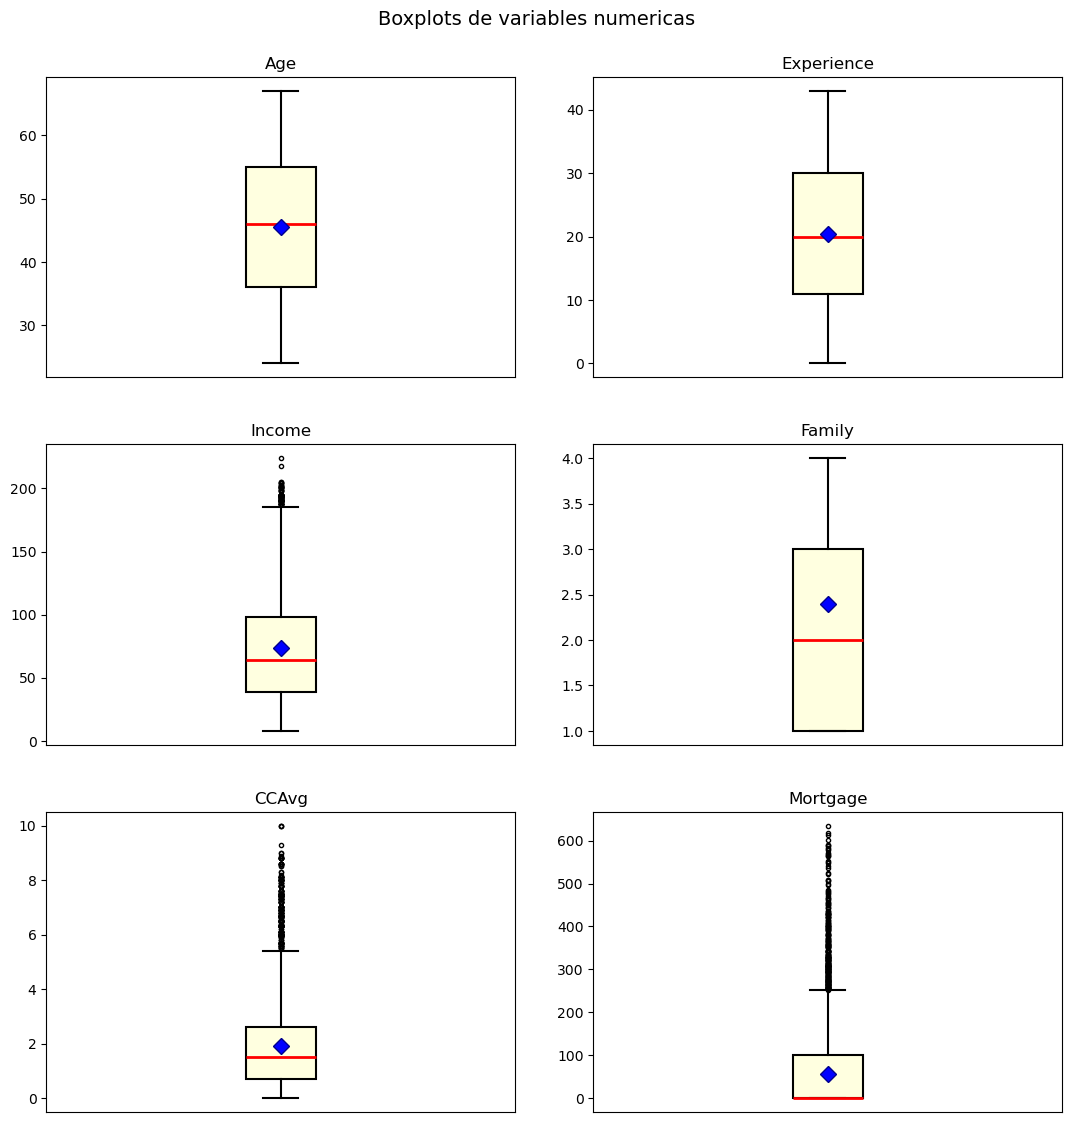

In [8]:
import matplotlib.pyplot as plt
import scipy.stats as stats

#Histogramas
Fig1 = plt.figure(figsize = (12, 12))
i = 0

for Col in num_cols:
    i += 1
    Ax = Fig1.add_subplot(3, 2, i)

    #Histograma
    x = Data[Col]
    Ax.hist(x, bins = 20, density = True, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    
    xmin, xmax = plt.xlim()
    xs = np.linspace(xmin, xmax, 100)

    #Curva normal teorica
    mu = Stat.loc['mean', Col]
    sigma = Stat.loc['std', Col]
    y1 = stats.norm.pdf(xs, mu, sigma)
    Ax.plot(xs, y1, color = 'red', ls = '-', lw = 1.8, label = 'Normal')

    #KDE
    kde = stats.gaussian_kde(x)
    y2 = kde(xs)
    Ax.plot(xs, y2, color = 'blue', ls = '-', lw = 1.8, label = 'KDE')

    #Media
    Ax.axvline(mu, color = 'black', ls = '--', lw = 1.8, label = 'Media')

    Ax.set_title(Col)
    Ax.legend(loc = 'best', fontsize = 'small', framealpha = 0.99)

Fig1.suptitle('Histogramas de variables numericas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])


#Boxplot
Fig2 = plt.figure(figsize = (12, 12))
i = 0

for Col in num_cols:
    i += 1
    Ax = Fig2.add_subplot(3, 2, i)

    #Boxplot
    x = Data[Col]
    Ax.boxplot(x, vert = True, patch_artist = True, boxprops = dict(facecolor = 'lightyellow', lw = 1.5), medianprops = dict(color = 'red', lw = 2), whiskerprops = dict(color = 'black', lw = 1.5), 
               capprops = dict(color = 'black', lw = 1.5), flierprops = dict(marker = 'o', ms = 3),
               showmeans = True, meanprops = dict(marker = 'D', ms = 8, mfc = 'blue', mec = 'darkblue'))

    Ax.set_title(Col)
    Ax.set_xticks([])

Fig2.suptitle('Boxplots de variables numericas', fontsize = 14)    
Fig2.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
        

**Observaciones:**  
1. **Age**. En el boxplot se observa como su media y mediana se encuentran muy cerca la una de la otra, también se puede apreciar una cierta simetría en los bigotes del gráfico. Esto se verifica en el histograma donde también se ve simetría en su forma y en la forma del KDE, y por este motivo presento un valor Skew cercano a cero (-0.02). Sin embargo el histograma no muestra un comportamiento normal sino más bien una forma achatada o platicúrtica, lo cual coincide con un valor Kurt bajo (-1.16).
2. **Experience**. Muy similar a Age, se observa cierta simetría tanto en el boxplot, el histograma y coincide con un Skew cercano a cero (-0.02). El histograma muestra también una forma achatada que coincide con un Kurt bajo (-1.13).
3. **Income**. En el boxplot se observa una ligera separación entre media y mediana así como una asimetría evidente en los bigotes del gráfico. En el histograma se ve como los datos están mas cargados del lado izquerdo y la cola se extiende del lado derecho (sesgo derecho), lo cual es lo esperado teniendo una media > mediana. Esta asimetría también es validada por el Skew más alto (0.84), aunque tampoco es demasiado alto para considerarlo altamente asimétrico. Por otro lado, el histograma ya no se ve achatado como en el caso anterior, y salvo por la asimetría ya luce más cercano a la normal. Esto coincide con un valor de Kurt más cercano a 0 (-0.05) que representa una forma mesocúrtica.
4. **Family**. En el boxplot se observa más separación entre media y mediana y una falta completa de simetría (solo tiene un bigote). Sin embargo si se observa cierta simetría en el histograma y presenta un Skew cercano a cero (0.16), por lo que se podría decir que si es aprox. simétrico. Sobre el Kurt, presenta un valor bajo (1.40) lo cual coincide con la forma achatada o platicúrtica del histograma. 
5. **CCAvg**. En el boxplot también se observa separación entre media y mediana, con media > mediana, y una asimetría en los bigotes. El valor de Skew también muestra asimetría teniendo un valor alto (1.59) y esto se confirma en el histograma donde, similar a Income, los valores se agrupan en el lado izquierdo y presenta cola larga en el lado derecho (sesgo derecho). Sobre su valor de Kurt, este es alto indicando una forma picuda o leptocúrtica, que también se observa en el histograma, en donde son pocos los bloques que tienen valores altos y estos decrecen rapidamente.
6. **Mortgage**. En el boxplot también presenta una media mayor a la mediana, y asimetría evidente en los bigotes. Su valor de Skew es el más alto hasta el momento (2.10), indicando también asimetría, que se observa evidente en el histograma (muchos valores cercanos a cero y cola a la derecha <> sesgo derecho). Su valor de Kurt es también el más alto (4.76) y eso coincide con su forma altamente picuda o leptocúrtica en el cero.

8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

Estadistica descriptiva de las variables categoricas:

        ZIP Code  Education  Personal Loan  Securities Account  CD Account  \
count       4941       4941           4941                4941        4941   
unique       467          3              2                   2           2   
top        94720          1              0                   0           0   
freq         163       2079           4462                4426        4640   

        Online  CreditCard  
count     4941        4941  
unique       2           2  
top          1           0  
freq      2951        3489  

Graficas: 

*Columnas con mas de 10 categorias: ZIP Code


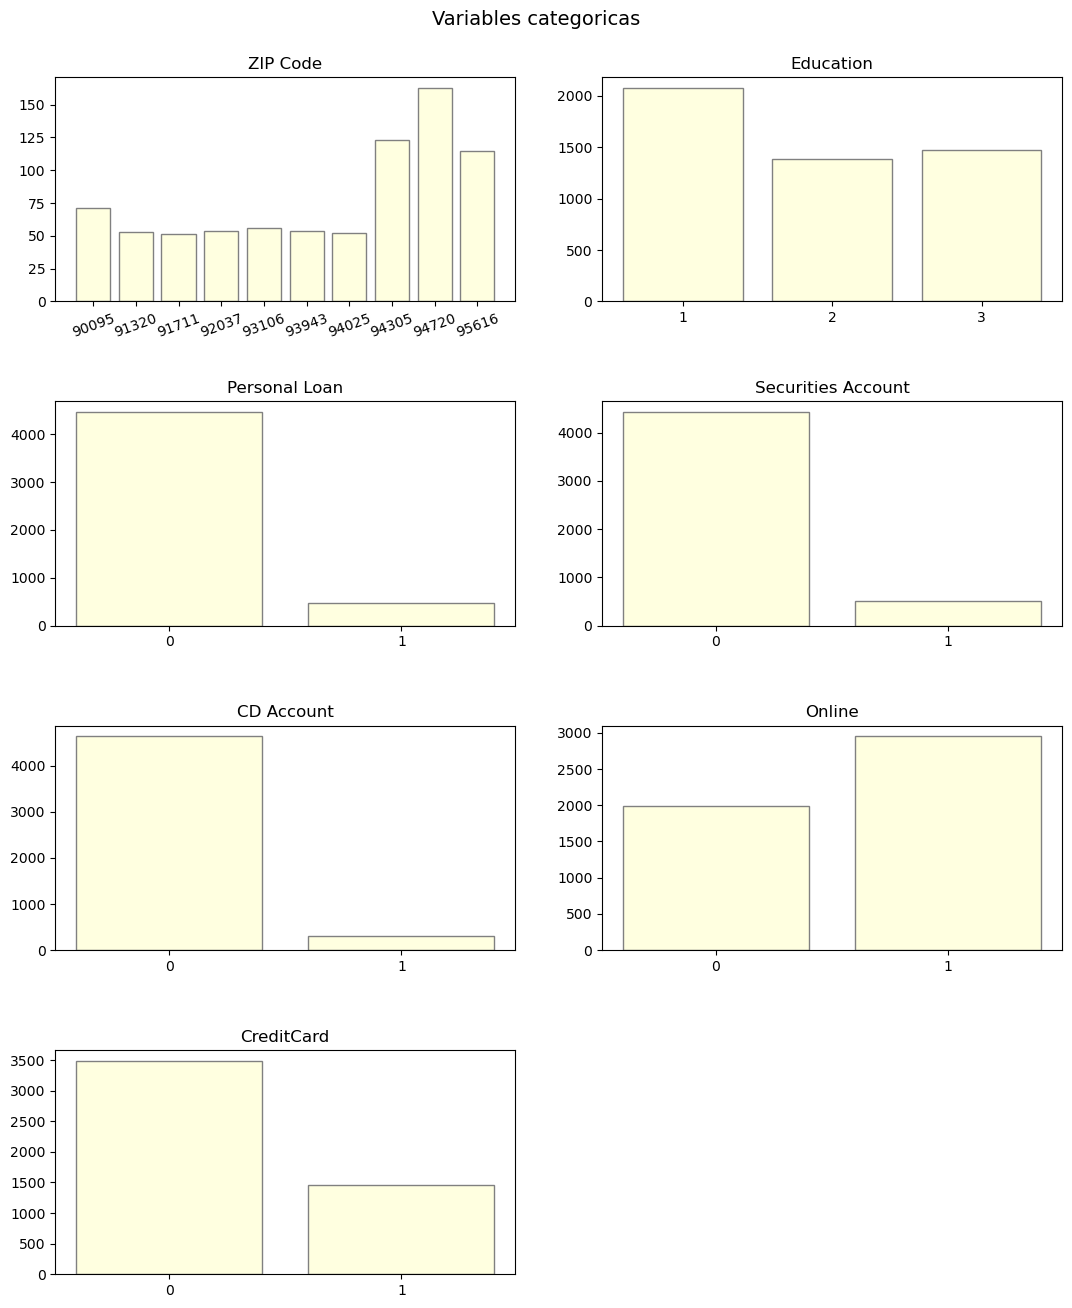

In [9]:
#Obtener estadísticas de las "nuevas" columnas categoricas
Stat = Data[cat_cols].describe()

#Imprimir resultados
print('Estadistica descriptiva de las variables categoricas:\n')
print(Stat.round(2))
print('\nGraficas: \n')

#Histogramas
Fig1 = plt.figure(figsize = (12, 14))
i = 0

cat_long = []
for Col in cat_cols:
    i += 1
    Ax = Fig1.add_subplot(4, 2, i)

    #Grafico de barras
    Counts = Data[Col].value_counts()
    if len(Counts) > 10:
        Counts = Counts.head(10)
        cat_long += [Col]
    
    Counts.sort_index(inplace = True)

    Ax.bar(Counts.index.astype(str), Counts.values, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    
    Ax.set_title(Col)
    if Col == 'ZIP Code':
        Ax.tick_params(axis = 'x', rotation = 20)


Fig1.suptitle('Variables categoricas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])

print(f'*Columnas con mas de 10 categorias: {', '.join(cat_long)}')


# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

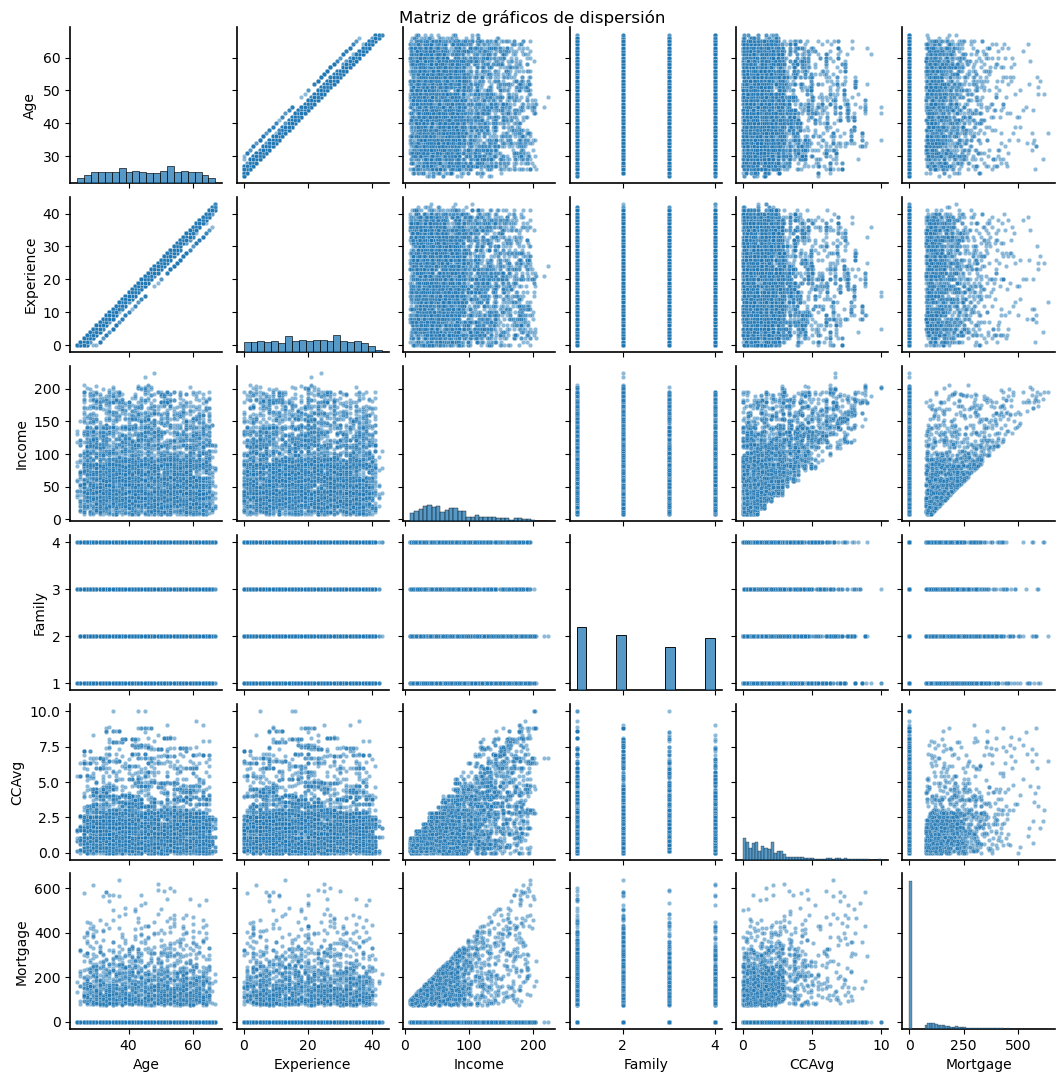

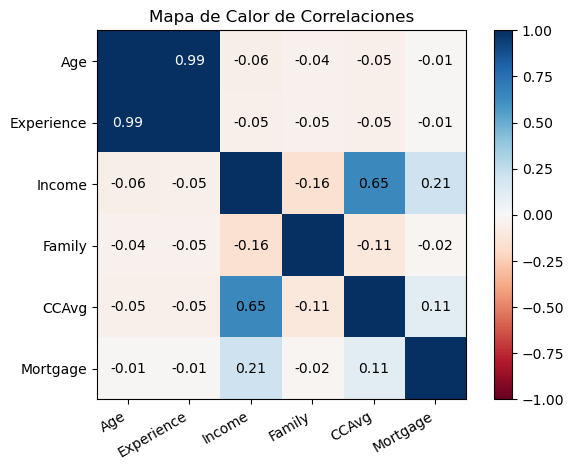

In [10]:
import seaborn as sns

#Generar matriz de graficos de dispersion de todas las variables
g = sns.pairplot(Data[num_cols], plot_kws = {'s': 10, 'alpha': 0.5}, height = 1.8)
g.figure.suptitle('Matriz de gráficos de dispersión', fontsize = 12, y = 1)

#Agregar separadores
for Ax in g.axes.flatten():
    if Ax is not None:
        for spine in Ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.2)

plt.show()

#Tomar solo columnas numericas y aplicar correlación de Pearson
Corr = Data[num_cols].corr(method = 'pearson')
nCorr = len(Corr.columns)

#Crear figura
Fig1 = plt.figure()
Ax = Fig1.add_subplot(1, 1, 1)

#Dibujar mapa de calor
im = Ax.imshow(Corr, vmin = -1, vmax = 1, cmap = 'RdBu')

#Etiquetas
Ax.set_xticks(range(nCorr))
Ax.set_yticks(range(nCorr))

Ax.set_xticklabels(Corr.columns, rotation = 30, ha = 'right')
Ax.set_yticklabels(Corr.columns)

#Agregar valores
for i in range(nCorr):
    for j in range(nCorr):
        if i != j:
            TxtColor = 'white' if abs(Corr.iloc[i,j]) > 0.7 else 'black'
            Ax.text(j, i, f'{Corr.iloc[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 10, color = TxtColor)

# Barra de colores
Fig1.colorbar(im)

Ax.set_title('Mapa de Calor de Correlaciones')

Fig1.tight_layout()

**Comentarios:**  
La correlación mas fuerte entre las diferentes variables la tiene **Age** y **Experience**. En el gráfico se puede observar como ambos parametros se centran alrededor de la grafica identidad (x = y), por lo que tienen una relación positiva prácticamente perfecta. Esto corresponde muy bien al ver su correlación de Pearson la cual es muy cercana a 1. Esto podría tener sentido si pensamos que a mayor edad, la gente acumula más experiencia laboral.  
La segunda correlación más fuerte se tiene entre **Income** y **CCAvg**, según la correlación de Pearson, de manera directa. Esto también tiene sentido, se puede interpretar que mientras más recurso tienen los clientes, mayor es el gasto mensual que se pueden permitir. 

10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


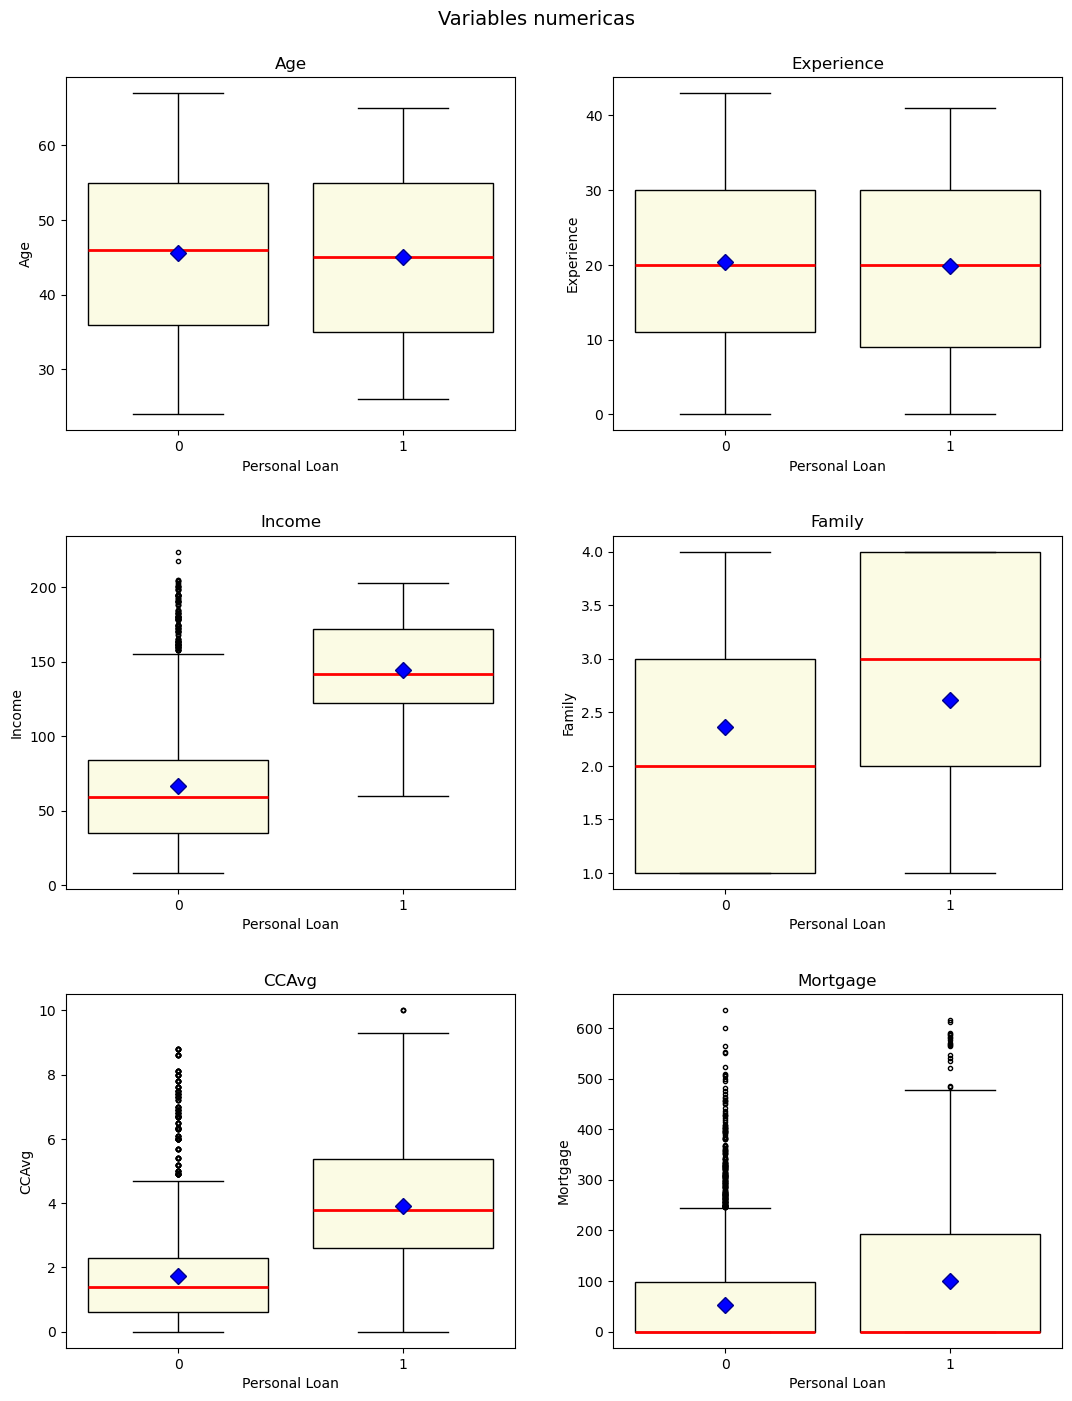

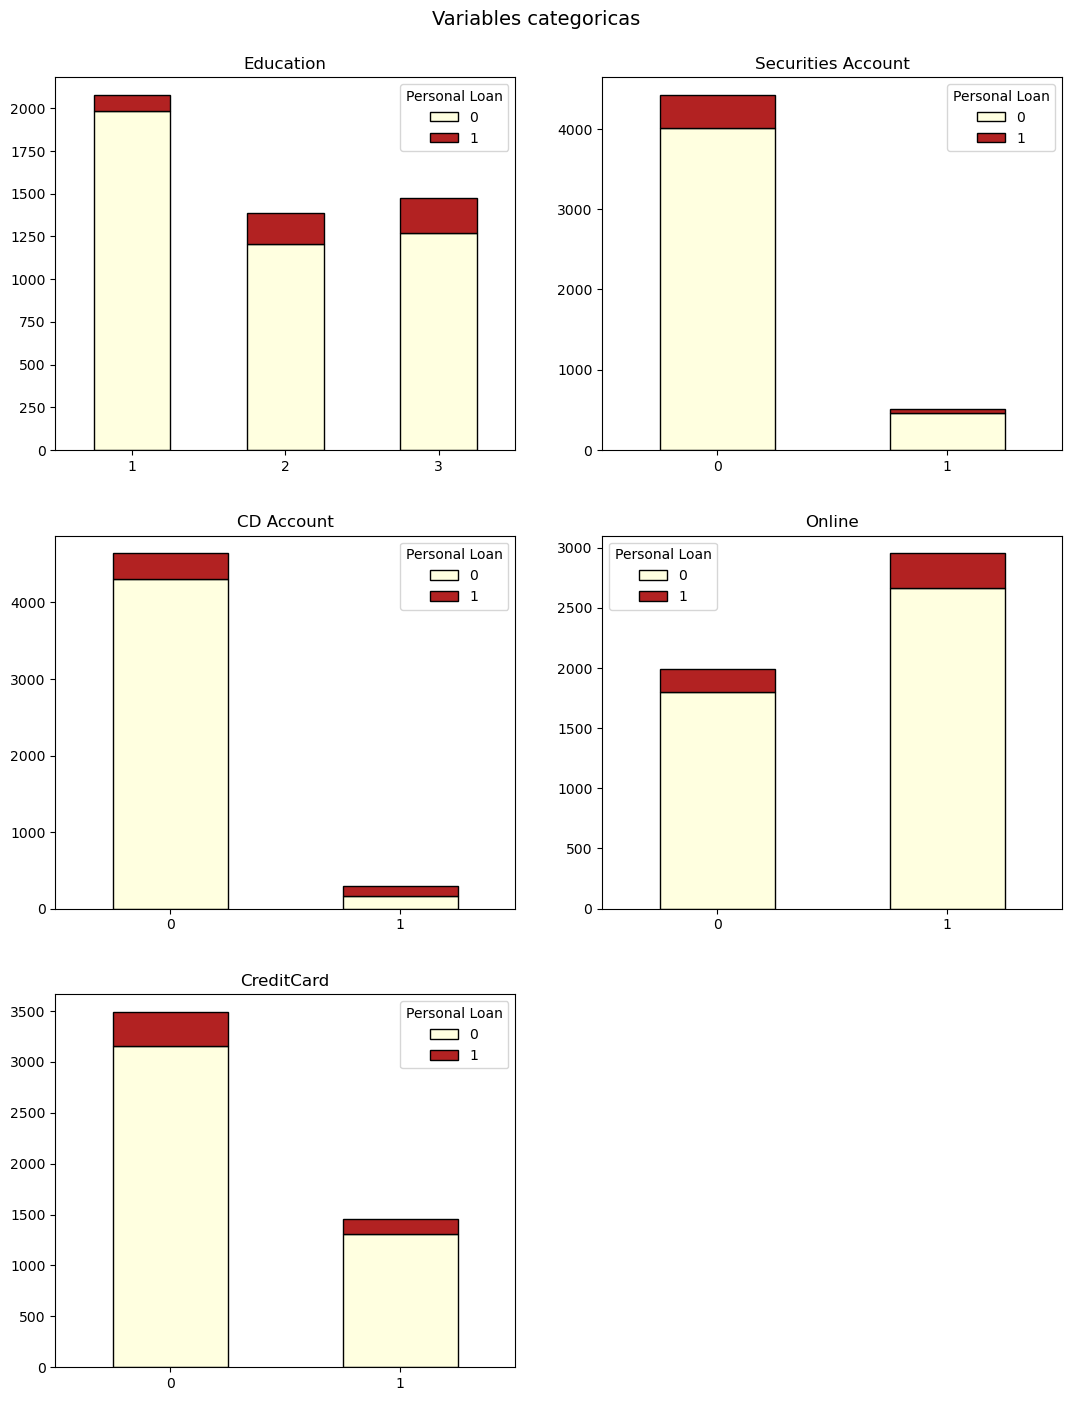

In [11]:
#Boxplots para variables numericas
Fig1 = plt.figure(figsize = (12, 15))

i = 0
for Col in num_cols:
    i += 1
    Ax = Fig1.add_subplot(3, 2, i)

    sns.boxplot(x = 'Personal Loan', y = Col, data = Data, ax = Ax, color = 'lightyellow', fliersize = 3, showmeans = True, linecolor = 'black', 
                medianprops={'color': 'red', 'linewidth': 2, 'linestyle': '-'}, 
                meanprops = {'marker': 'D', 'markerfacecolor': 'blue', 'markeredgecolor': 'darkblue', 'markersize': 8})

    Ax.set_title(Col)

Fig1.suptitle('Variables numericas', fontsize = 14)   
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])


#Graficos de barra para variables categoricas
Fig2 = plt.figure(figsize = (12, 15))
i = 0
for Col in [v for v in cat_cols if (v != 'Personal Loan') and (v != 'ZIP Code')]: #Omite Personal Loan y Zip Code
    i += 1
    Ax = Fig2.add_subplot(3, 2, i)

    tabla = pd.crosstab(Data[Col], Data['Personal Loan'])
    tabla.plot(kind = 'bar', stacked = True, ax = Ax, color = ['lightyellow','firebrick'], edgecolor = 'black')

    Ax.set(xlabel = None)
    Ax.set_title(Col)

    Ax.tick_params(axis = 'x', rotation = 0)
    Ax.tick_params(axis = 'y', rotation = 0)

Fig2.suptitle('Variables categoricas', fontsize = 14)    
Fig2.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])


**Hallazgos por grupo de variables:**  
**Numéricas**: Se observa gran similitud en las parejas de boxplots para Age y Experience (Experience se sabe que esta fuertemente correlacionado directamente a Age). Esto implicaría que la edad no es un factor relevante para predecir si un cliente va a aceptar o no un préstamo personal. De forma opuesta, donde si se observa una gran diferencia es en Income y CCAvg (CCAvg se sabe que esta correlacionado directamente a Income). Esto podríamos interpretarlo a que mientras mayor sea el ingreso del cliente, probablemente más cómodo le sea pagar algún préstamo personal y por lo tanto lo acepta, o bien, al tener un ingreso estable entonces tiene mayor posibilidad que le aprueben creditos personales.  
**Categóricas**: Lo principal que se puede observar es como los clientes que tienen un menor nivel educativo (graduado) tienen un menor número de créditos personales que los que tienen mayor nivel, incluso cuándo sea la mayor cantidad de población en la BD. Esto también podría deberse a la hipótesis que teníamos relacionada con el ingreso, quizá con mayores estudios es más fácil que las entidades bancarias les acepten o les promocionen más préstamos.

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---